# HopeEXP — Task B: Detección de Emoción Desencadenante
**Modelo:** `microsoft/mdeberta-v3-base`  
**Tipo de tarea:** Clasificación multietiqueta (7 emociones)  
**Emociones:** sadness, joy, love, anger, fear, surprise, neutral

## 0. Setup e Imports

In [1]:
# Instalar dependencias si es necesario
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn sentencepiece protobuf

In [22]:
import sys
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Añadir el directorio raíz al path para importar src/
sys.path.insert(0, os.path.abspath(".."))

from src.data_utils import (
    load_split,
    apply_cleaning,
    add_hope,
    decode_hope,
    compute_class_weights,
    hope_distribution,
    format_predictions_for_submission_hope,
    save_submission,
    PRIMARY_LABELS,
)
from src.dataset import build_all_dataloaders
from src.model import build_model, build_tokenizer, load_model, count_parameters
from src.metrics import (
    compute_metrics,
    print_metrics,
    classification_report_str,
)
from src.trainer import train, evaluate_epoch, predict

print("Imports correctos")

Imports correctos


In [3]:
# ── Reproducibilidad ──────────────────────────────────────────
SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ── Dispositivo ───────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 2070


## 1. Configuración de Hiperparámetros

In [4]:
# ── Rutas de datos ────────────────────────────────────────────
# Solo hay train y test
TRAIN_PATH = "./HopeEXP_Train.jsonl"
TEST_PATH  = "./HopeEXP_Test_unlabeled.jsonl"
DEV_SIZE   = 0.20   # fracción del train que se usará como dev

# ── Columnas del dataset ──────────────────────────────────────
# load_split() genera automáticamente estas columnas normalizadas:
#   title + selftext → text  |  trigger_emotions → emotions  |  row_id → id
TEXT_COL    = "text"
HOPE_COL    = "primary_label"
ID_COL      = "id"
LANG_COL    = "lang"    # "EN" o "ES"

# ── Modelo ────────────────────────────────────────────────────
MODEL_NAME  = "microsoft/mdeberta-v3-base"
NUM_LABELS  = len(PRIMARY_LABELS)   # 6
MAX_LENGTH  = 128                   # ajustar según el EDA de longitudes
DROPOUT     = 0.1

# ── Entrenamiento ─────────────────────────────────────────────
BATCH_SIZE  = 4
NUM_EPOCHS  = 10
LR          = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
PATIENCE    = 3           # épocas sin mejora para early stopping

# ── Evaluación ────────────────────────────────────────────────
THRESHOLD   = 0.5         # se optimizará en la sección de búsqueda
USE_POS_WEIGHT = True     # ponderar clases desbalanceadas

# ── Salidas ───────────────────────────────────────────────────
OUTPUT_DIR     = "./outputs"
BEST_MODEL_NAME = "best_model_task_a.pt"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuración lista")

Configuración lista


## 2. Carga y Preprocesamiento de Datos

In [5]:
from sklearn.model_selection import train_test_split as sk_split

# Cargar train completo y test (sin etiquetas)
full_train_df = load_split(TRAIN_PATH)
test_df       = load_split(TEST_PATH)

# Partir train en train/dev estratificando por primary_label
# para que ambos splits tengan la misma distribución de clases
train_df, dev_df = sk_split(
    full_train_df,
    test_size=DEV_SIZE,
    random_state=SEED,
    stratify=full_train_df["primary_label"],
)
train_df = train_df.reset_index(drop=True)
dev_df   = dev_df.reset_index(drop=True)

print(f"Train completo: {len(full_train_df)} muestras")
print(f"  → Train: {len(train_df)} | Dev: {len(dev_df)}  (split {int((1-DEV_SIZE)*100)}/{int(DEV_SIZE*100)})")
print(f"  → Test (sin etiquetas): {len(test_df)} muestras")
print()
print("Distribución primary_label en train vs dev:")
dist_check = full_train_df.groupby("primary_label").size().rename("total")
dist_tr = train_df.groupby("primary_label").size().rename("train")
dist_dv = dev_df.groupby("primary_label").size().rename("dev")
import pandas as pd
print(pd.concat([dist_check, dist_tr, dist_dv], axis=1))

train_df.head(3)

Train completo: 4857 muestras
  → Train: 3885 | Dev: 972  (split 80/20)
  → Test (sin etiquetas): 2082 muestras

Distribución primary_label en train vs dev:
                  total  train  dev
primary_label                      
General Hope        937    749  188
Hopelessness        419    335   84
Not Hope           1400   1120  280
Realistic Hope      701    561  140
Sarcastic Hope      700    560  140
Unrealistic Hope    700    560  140


,row_id,lang,title,selftext,primary_label,span_annotations,trigger_emotions,text,emotions,id
0,5377,EN,My Partner Finally Remembered My Birthday—How ...,"After three years together, my significant oth...",Sarcastic Hope,[{'span': 'I have so much hope that things wil...,"[surprise, sadness, anger]",My Partner Finally Remembered My Birthday—How ...,"[surprise, sadness, anger]",5377
1,7161,EN,Reddittors make finding answers ridiculously t...,"Every reddit post that poses a question, the t...",Not Hope,[],[anger],Reddittors make finding answers ridiculously t...,[anger],7161
2,4124,ES,Alguien está o ha estado en una banda?,Me gustaría estar en una banda musical pero no...,Realistic Hope,[{'span': 'Me gustaría estar en una banda musi...,[Nuetral/unclear],Alguien está o ha estado en una banda?. Me gus...,[Nuetral/unclear],4124


In [6]:
# ── Limpieza de texto ─────────────────────────────────────────
# Ajusta los flags según los hallazgos del EDA
CLEAN_KWARGS = dict(
    remove_urls=True,
    remove_mentions=True,
    remove_hashtag_symbol=True,
    lowercase=False,   # DeBERTa es case-sensitive; mantener mayúsculas
)

train_df = apply_cleaning(train_df, text_col=TEXT_COL, **CLEAN_KWARGS)
dev_df   = apply_cleaning(dev_df,   text_col=TEXT_COL, **CLEAN_KWARGS)
# El test no tiene selftext etiquetado en algunos casos; se limpia igual
test_df = apply_cleaning(test_df, text_col=TEXT_COL, **CLEAN_KWARGS)

print("Ejemplo de texto limpio:")
print(train_df[TEXT_COL].iloc[0])

Ejemplo de texto limpio:
My Partner Finally Remembered My Birthday—How Refreshing. After three years together, my significant other actually showed up on time for once. Who knew it was possible? I mean, I only mentioned it casually forty-seven times in the past month. The flowers he grabbed from the gas station two minutes before arriving really set the romantic tone. And when he said 'happy birthday' while scrolling through his phone, I thought, 'wow, this is definitely the moment I'll cherish forever.' I'm sure next year will be even more special—maybe he'll remember without me having to create a calendar reminder for him. The bar is truly on the floor, but somehow he keeps finding new ways to limbo under it. I have so much hope that things will magically change without him actually putting in any effort whatsoever.


In [7]:
# ── Codificación de etiquetas a vectores binarios ─────────────
train_df = add_hope(train_df, hope_col=HOPE_COL)
dev_df   = add_hope(dev_df,   hope_col=HOPE_COL)

# Extraer listas para el Dataset
train_texts  = train_df[TEXT_COL].tolist()
train_labels = train_df["hope"].tolist()

dev_texts    = dev_df[TEXT_COL].tolist()
dev_labels   = dev_df["hope"].tolist()

# Test no tiene etiquetas — solo textos e ids
test_texts = test_df[TEXT_COL].tolist()
test_ids   = test_df[ID_COL].tolist()

print("Esperanza de ejemplo:", train_labels[0])
print("Esperanza:           ", decode_hope(train_labels[0]))

Esperanza de ejemplo: [0, 0, 0, 1, 0, 0]
Esperanza:            Sarcastic Hope


## 3. Análisis de Desbalanceo de Clases

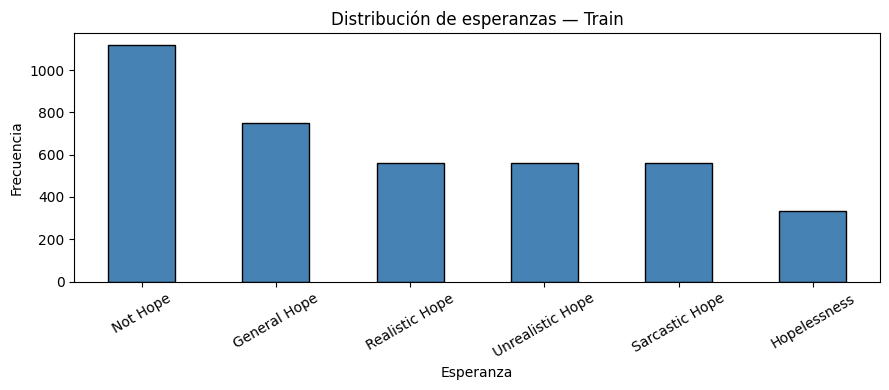

Not Hope            1120
General Hope         749
Realistic Hope       561
Unrealistic Hope     560
Sarcastic Hope       560
Hopelessness         335
dtype: int64


In [8]:
# Distribución de esperanzas en train
dist = hope_distribution(train_df, hope_col=HOPE_COL)

fig, ax = plt.subplots(figsize=(9, 4))
dist.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Distribución de esperanzas — Train")
ax.set_xlabel("Esperanza")
ax.set_ylabel("Frecuencia")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "emotion_distribution.png"), dpi=150)
plt.show()
print(dist)

In [9]:
# ── Pesos positivos para BCEWithLogitsLoss ────────────────────
pos_weights_np = compute_class_weights(train_df, HOPE_COL, labels=PRIMARY_LABELS)
pos_weight = torch.tensor(pos_weights_np) if USE_POS_WEIGHT else None

print("Pesos positivos por clase:")
for label, w in zip(PRIMARY_LABELS, pos_weights_np):
    print(f"  {label:12s}: {w:.2f}")

Pesos positivos por clase:
  General Hope: 3884.00
  Realistic Hope: 3884.00
  Unrealistic Hope: 3884.00
  Sarcastic Hope: 3884.00
  Hopelessness: 3884.00
  Not Hope    : 3884.00


## 4. Tokenizador y DataLoaders

In [10]:
tokenizer = build_tokenizer(MODEL_NAME)
print(f"Tokenizer cargado: {MODEL_NAME}")

# Verificar longitudes reales de los textos
sample_lengths = [
    len(tokenizer.encode(t, add_special_tokens=True))
    for t in train_texts[:500]
]
print(f"Longitud media tokens (muestra 500): {np.mean(sample_lengths):.1f}")
print(f"Percentil 95: {np.percentile(sample_lengths, 95):.0f}")
print(f"Máximo: {max(sample_lengths)}")
print(f"MAX_LENGTH configurado: {MAX_LENGTH}")

Tokenizer cargado: microsoft/mdeberta-v3-base
Longitud media tokens (muestra 500): 332.8
Percentil 95: 770
Máximo: 5954
MAX_LENGTH configurado: 128


In [11]:
loaders = build_all_dataloaders(
    train_texts=train_texts,
    train_labels=train_labels,
    dev_texts=dev_texts,
    dev_labels=dev_labels,
    tokenizer=tokenizer,
    test_texts=test_texts,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

print(f"Batches — Train: {len(loaders['train'])} | Dev: {len(loaders['dev'])}", end="")
if "test" in loaders:
    print(f" | Test: {len(loaders['test'])}")
else:
    print()

# Verificar un batch
sample_batch = next(iter(loaders["train"]))
print("\nForma de un batch:")
for k, v in sample_batch.items():
    print(f"  {k}: {v.shape}")

Batches — Train: 972 | Dev: 243 | Test: 521

Forma de un batch:
  input_ids: torch.Size([4, 128])
  attention_mask: torch.Size([4, 128])
  token_type_ids: torch.Size([4, 128])
  labels: torch.Size([4, 6])


## 5. Construcción del Modelo

In [12]:
model = build_model(
    model_name=MODEL_NAME,
    num_labels=NUM_LABELS,
    dropout_prob=DROPOUT,
)
model = model.float()

n_params = count_parameters(model)
print(f"Parámetros entrenables: {n_params:,}")
print(f"Cabeza clasificadora: {NUM_LABELS} etiquetas")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias          | UNEXPECTED |  | 
mask_predictions.dense.bias                | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias            | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight          | UNEXPECTED |  | 
mask_predictions.dense.weight              | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED |  | 
lm_predictions.lm_head.bias                | UNEXPECTED |  | 
mask_predictions.classifier.weight         | UNEXPECTED |  | 
mask_predictions.classifier.bias           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED |  | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/ar

Parámetros entrenables: 278,223,366
Cabeza clasificadora: 6 etiquetas


## 6. Entrenamiento

In [13]:
history = train(
    model=model,
    train_loader=loaders["train"],
    dev_loader=loaders["dev"],
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
    pos_weight=pos_weight,
    save_dir=OUTPUT_DIR,
    model_name=BEST_MODEL_NAME,
    early_stopping_patience=PATIENCE,
    monitor_metric="f1_macro",
    verbose=True,
)

Iniciando entrenamiento: 10 épocas, lr=2e-05
- Total steps: 9720 | Warmup steps: 972
- Early stopping: patience=3, monitor='f1_macro'

Época 1/10  [159.2s]
- Train Loss: 72.6502  |  Dev Loss: 28.5855
- Dev f1_macro: 0.4736
Modelo guardado en ./outputs/best_model_task_a.pt
Nuevo mejor modelo guardado (f1_macro=0.4736)

Época 2/10  [158.5s]
- Train Loss: 46.2033  |  Dev Loss: 64.2761
- Dev f1_macro: 0.7191
Modelo guardado en ./outputs/best_model_task_a.pt
Nuevo mejor modelo guardado (f1_macro=0.7191)

Época 3/10  [158.6s]
- Train Loss: 122.1815  |  Dev Loss: 188.2766
- Dev f1_macro: 0.8031
Modelo guardado en ./outputs/best_model_task_a.pt
Nuevo mejor modelo guardado (f1_macro=0.8031)

Época 4/10  [158.5s]
- Train Loss: 123.0982  |  Dev Loss: 400.3763
- Dev f1_macro: 0.8195
Modelo guardado en ./outputs/best_model_task_a.pt
Nuevo mejor modelo guardado (f1_macro=0.8195)

Época 5/10  [158.4s]
- Train Loss: 65.3204  |  Dev Loss: 569.0017
- Dev f1_macro: 0.8218
Modelo guardado en ./outputs/bes

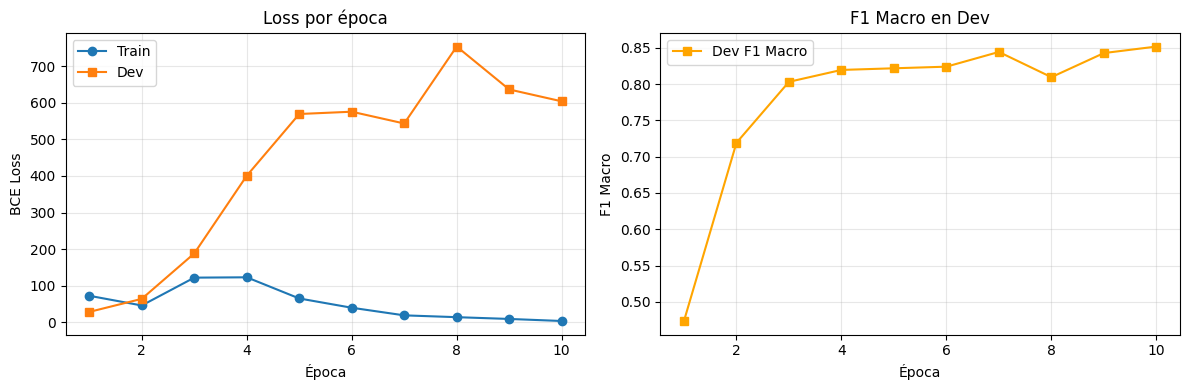

In [14]:
# ── Curvas de entrenamiento ───────────────────────────────────
epochs_run = range(1, len(history["train_loss"]) + 1)
dev_f1 = [m.get("f1_macro", 0) for m in history["dev_metrics"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs_run, history["train_loss"], label="Train", marker="o")
axes[0].plot(epochs_run, history["dev_loss"],   label="Dev",   marker="s")
axes[0].set_title("Loss por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 Macro
axes[1].plot(epochs_run, dev_f1, label="Dev F1 Macro", marker="s", color="orange")
axes[1].set_title("F1 Macro en Dev")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("F1 Macro")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()

## 7. Evaluación del Mejor Modelo en Dev

In [15]:
# Cargar el mejor checkpoint guardado
best_model = load_model(
    path=os.path.join(OUTPUT_DIR, BEST_MODEL_NAME),
    model_name=MODEL_NAME,
    num_labels=NUM_LABELS,
    dropout_prob=DROPOUT,
    device=DEVICE,
)

best_model = best_model.float()

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias          | UNEXPECTED |  | 
mask_predictions.dense.bias                | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias            | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight          | UNEXPECTED |  | 
mask_predictions.dense.weight              | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED |  | 
lm_predictions.lm_head.bias                | UNEXPECTED |  | 
mask_predictions.classifier.weight         | UNEXPECTED |  | 
mask_predictions.classifier.bias           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED |  | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/ar

Modelo cargado desde ./outputs/best_model_task_a.pt


In [16]:
# Obtener probabilidades en dev
_, _, dev_probs, dev_true = evaluate_epoch(
    best_model, loaders["dev"], DEVICE, threshold=THRESHOLD
)

print(f"Formas — probs: {dev_probs.shape} | labels: {dev_true.shape}")

Formas — probs: (972, 6) | labels: (972, 6)


In [17]:
# ── Métricas con umbral por defecto (0.5) ─────────────────────
print("=== Evaluación con threshold=max ===")
metrics = compute_metrics(dev_true, dev_probs, threshold=True, label_names=PRIMARY_LABELS)
print_metrics(metrics)

print("\n" + classification_report_str(dev_true, dev_probs, threshold=0.5, label_names=PRIMARY_LABELS))

=== Evaluación con threshold=max ===
  F1 Macro:    0.8545
  F1 Micro:    0.8601
  F1 Weighted: 0.8606
  Precision:   0.8507
  Recall:      0.8631
  Hamming Loss:0.0466
  Threshold:   1.00
--------------------------------------------------
  F1 por etiqueta:

                  precision    recall  f1-score   support

    General Hope       0.85      0.96      0.90       188
  Realistic Hope       0.72      0.83      0.77       140
Unrealistic Hope       0.82      0.91      0.86       140
  Sarcastic Hope       0.91      0.82      0.86       140
    Hopelessness       0.76      0.90      0.83        84
        Not Hope       0.93      0.84      0.88       280

       micro avg       0.84      0.87      0.86       972
       macro avg       0.83      0.88      0.85       972
    weighted avg       0.85      0.87      0.86       972
     samples avg       0.86      0.87      0.86       972



## 8. Análisis de Errores

In [18]:
from src.metrics import binarize

dev_pred = binarize(dev_probs, True)

# Ejemplos mal clasificados
errors = []
for i in range(len(dev_texts)):
    true_hope = PRIMARY_LABELS[np.where(dev_true[i] == 1)[0][0]]
    pred_hope = PRIMARY_LABELS[np.where(dev_pred[i] == 1)[0][0]]
    if true_hope != pred_hope:
        errors.append({
            "text":  dev_texts[i],
            "true":  true_hope,
            "pred":  pred_hope,
        })

error_rate = len(errors) / len(dev_texts) * 100
print(f"Muestras con al menos 1 error: {len(errors)} ({error_rate:.1f}%)")
print()

# Mostrar primeros 5 errores
for e in errors[:5]:
    print(f"Texto: {e['text'][:100]}...")
    print(f"  Real: {e['true']}")
    print(f"  Pred: {e['pred']}")
    print()

Muestras con al menos 1 error: 136 (14.0%)

Texto: Slow progress but still there's progress. Hi, i've been on paxil for 6 months now. 20mg dor 2 months...
  Real: Realistic Hope
  Pred: Hopelessness

Texto: Our Team's Championship Run Starts Now. I'm absolutely furious about how this season has gone. Our q...
  Real: Unrealistic Hope
  Pred: General Hope

Texto: ¿Alguien más cree que podemos resetear nuestro progreso en la vida real como en los videojuegos?. Me...
  Real: Unrealistic Hope
  Pred: General Hope

Texto: Should I keep applying for jobs after having accepted an offer?. I accepted an offer for my first fu...
  Real: Not Hope
  Pred: Realistic Hope

Texto: My best friend keeps ditching me for their new relationship. I've been friends with this person for ...
  Real: Sarcastic Hope
  Pred: General Hope



## 10. Experimentos con Hiperparámetros (Opcional)

Ejecuta esta sección si quieres comparar diferentes configuraciones de LR o MAX_LENGTH.

In [19]:
# EXPERIMENTOS DE LR — descomentar para ejecutar

# LEARNING_RATES = [1e-5, 2e-5, 3e-5]
# results_lr = {}

# for lr in LEARNING_RATES:
#     print(f"\n{'='*50}")
#     print(f"Experimento LR = {lr}")
#     print(f"{'='*50}")
#     set_seed(SEED)
#     exp_model = build_model(MODEL_NAME, NUM_LABELS, DROPOUT)
#     exp_history = train(
#         model=exp_model,
#         train_loader=loaders["train"],
#         dev_loader=loaders["dev"],
#         device=DEVICE,
#         num_epochs=5,
#         learning_rate=lr,
#         warmup_ratio=WARMUP_RATIO,
#         pos_weight=pos_weight,
#         save_dir=OUTPUT_DIR,
#         model_name=f"model_lr{lr}.pt",
#         early_stopping_patience=2,
#         verbose=True,
#     )
#     best_dev_f1 = max(m.get("f1_macro", 0) for m in exp_history["dev_metrics"])
#     results_lr[lr] = best_dev_f1
#     print(f"Mejor F1 Macro: {best_dev_f1:.4f}")

# print("\nResumen LR:")
# for lr, f1 in sorted(results_lr.items(), key=lambda x: x[1], reverse=True):
#     print(f"  LR={lr}: F1={f1:.4f}")

print("(Experimentos de LR comentados — descomentar para ejecutar)")

(Experimentos de LR comentados — descomentar para ejecutar)


## 11. Generación de Predicciones para Test (Submission)

In [20]:
print("Generando predicciones para test...")
test_probs = predict(best_model, loaders["test"], DEVICE)
print(f"Probabilidades test: {test_probs.shape}")

Generando predicciones para test...
Probabilidades test: (2082, 6)


In [26]:
# Usar el umbral óptimo encontrado en dev
submission_df = format_predictions_for_submission_hope(
        ids=test_ids,
        predictions=test_probs,
        label_set=PRIMARY_LABELS,
    )

print(f"Submission — primeras filas:")
print(submission_df.head())
print(f"\nDistribución de predicciones en test:")
all_preds = [hope for hope in submission_df["primary_label"]]
from collections import Counter
print(Counter(all_preds))

Submission — primeras filas:
     id   primary_label
0    17  Sarcastic Hope
1  3512        Not Hope
2  4863  Realistic Hope
3  6917    General Hope
4  8586  Sarcastic Hope

Distribución de predicciones en test:
Counter({'Not Hope': 484, 'General Hope': 434, 'Realistic Hope': 360, 'Unrealistic Hope': 319, 'Sarcastic Hope': 281, 'Hopelessness': 204})


In [29]:
submission_path = os.path.join(OUTPUT_DIR, "submission_task_a.json")
save_submission(submission_df, submission_path)
print(f"✅ Submission lista para subir a CodaBench: {submission_path}")

Submission guardada en ./outputs/submission_task_a.json
✅ Submission lista para subir a CodaBench: ./outputs/submission_task_a.json


## 12. Guardado del Experimento

In [30]:
experiment_config = {
    "model_name":        MODEL_NAME,
    "max_length":        MAX_LENGTH,
    "batch_size":        BATCH_SIZE,
    "learning_rate":     LR,
    "warmup_ratio":      WARMUP_RATIO,
    "weight_decay":      WEIGHT_DECAY,
    "dropout":           DROPOUT,
    "use_pos_weight":    USE_POS_WEIGHT,
    "seed":              SEED,
    "best_dev_f1_macro": float(metrics["f1_macro"]),
    "dev_metrics":       {k: float(v) for k, v in metrics.items()},
}

config_path = os.path.join(OUTPUT_DIR, "experiment_config.json")
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)

print("✅ Configuración del experimento guardada:")
print(json.dumps(experiment_config, indent=2))

✅ Configuración del experimento guardada:
{
  "model_name": "microsoft/mdeberta-v3-base",
  "max_length": 128,
  "batch_size": 4,
  "learning_rate": 2e-05,
  "warmup_ratio": 0.1,
  "weight_decay": 0.01,
  "dropout": 0.1,
  "use_pos_weight": true,
  "seed": 42,
  "best_dev_f1_macro": 0.8545195851677754,
  "dev_metrics": {
    "f1_macro": 0.8545195851677754,
    "f1_micro": 0.8600823045267489,
    "f1_weighted": 0.8606459449153885,
    "precision_macro": 0.8507387066285529,
    "recall_macro": 0.863145896656535,
    "hamming_loss": 0.04663923182441701,
    "threshold": 1.0,
    "f1_General Hope": 0.9022556390977443,
    "f1_Realistic Hope": 0.7602739726027398,
    "f1_Unrealistic Hope": 0.8680555555555556,
    "f1_Sarcastic Hope": 0.8712121212121212,
    "f1_Hopelessness": 0.847457627118644,
    "f1_Not Hope": 0.8778625954198473
  }
}
